# 05 — Climate forcing integration from NASA POWER (2013–2025)

This notebook builds the annual NASA POWER climate forcing table used by the Barranquilla LST/SUHI modeling workflow.

**Main purpose**

- Download or reuse daily NASA POWER variables for the model-domain centroid.
- Aggregate daily variables into annual climate descriptors for 2013–2025.
- Derive annual anomalies and interannual deltas.
- Generate the final climate input table used by the M5B model.
- Document why only two climate variables are retained as auxiliary predictors:
  - `delta_t2m_mean_Y_minus_Yminus1`
  - `delta_solar_radiation_mean_Y_minus_Yminus1`

**Important methodological note**

NASA POWER variables are used as annual regional descriptors associated with the model-domain centroid. They are **not** interpreted as pixel-level raster climate predictors.


In [1]:
# ============================================================
# CELL 1 — Imports and runtime setup
# ============================================================

from pathlib import Path
from datetime import datetime
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

warnings.filterwarnings("ignore")

try:
    from IPython.display import display
except Exception:
    display = print

# Optional Google Drive mount for Colab.
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
else:
    print("Not running in Colab. Local paths must be adjusted if needed.")

print("Runtime timestamp UTC:", datetime.utcnow().isoformat() + "Z")


Mounted at /content/drive
Runtime timestamp UTC: 2026-06-23T17:26:03.119602Z


In [2]:
# ============================================================
# CELL 2 — Project configuration
# ============================================================

PROJECT_DIR = Path("/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling")

# Reference grid used only to extract the model-domain centroid.
MODEL_DOMAIN_REFERENCE = (
    PROJECT_DIR
    / "01_aoi_reference"
    / "reference_grid"
    / "model_domain_reference.tif"
)

# Output directory for lightweight QA/reporting products.
QC05_DIR = (
    PROJECT_DIR
    / "00_documentation"
    / "quality_control"
    / "05_climate_forcing_integration_2013_2025"
)

FIG05_DIR = QC05_DIR / "figures"
BITACORA_DIR = PROJECT_DIR / "00_documentation" / "bitacoras"

for d in [QC05_DIR, FIG05_DIR, BITACORA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Operational annual period.
START_YEAR = 2013
END_YEAR = 2025

# Target years with complete T3 formulation.
TARGET_START_YEAR = 2016
TARGET_END_YEAR = 2025
TARGET_YEARS = list(range(TARGET_START_YEAR, TARGET_END_YEAR + 1))

# Fallback centroid if the reference raster is not available.
# This fallback is intentionally explicit and must be replaced by the model-domain centroid when available.
FALLBACK_DOMAIN_POINT = {
    "latitude": 10.975918770497753,
    "longitude": -74.86645650261003,
    "source": "fallback_from_previous_project_climate_workflow",
}

print("PROJECT_DIR:", PROJECT_DIR)
print("QC05_DIR:", QC05_DIR)
print("FIG05_DIR:", FIG05_DIR)
print("MODEL_DOMAIN_REFERENCE:", MODEL_DOMAIN_REFERENCE)
print("Operational years:", START_YEAR, "→", END_YEAR)
print("Target years:", TARGET_YEARS)


PROJECT_DIR: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling
QC05_DIR: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025
FIG05_DIR: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/figures
MODEL_DOMAIN_REFERENCE: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/01_aoi_reference/reference_grid/model_domain_reference.tif
Operational years: 2013 → 2025
Target years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [3]:
# ============================================================
# CELL 3 — Helper functions
# ============================================================

def expected_days_in_year(year: int) -> int:
    start = pd.Timestamp(year=year, month=1, day=1)
    end = pd.Timestamp(year=year, month=12, day=31)
    return len(pd.date_range(start, end, freq="D"))


def save_json(obj, out_path: Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    print("Saved JSON:", out_path)


def save_current_fig(out_path: Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved figure:", out_path)


def zscore_for_plot(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    std = s.std(ddof=0)
    if pd.isna(std) or std == 0:
        return s * np.nan
    return (s - s.mean()) / std


In [4]:
# ============================================================
# CELL 4 — Model-domain centroid in WGS84
# ============================================================

def get_domain_centroid_wgs84(reference_tif: Path, fallback: dict) -> dict:
    if reference_tif.exists():
        try:
            import rasterio
            from rasterio.warp import transform

            with rasterio.open(reference_tif) as src:
                bounds = src.bounds
                crs = src.crs
                x_center = (bounds.left + bounds.right) / 2
                y_center = (bounds.bottom + bounds.top) / 2
                lon, lat = transform(crs, "EPSG:4326", [x_center], [y_center])

            return {
                "latitude": float(lat[0]),
                "longitude": float(lon[0]),
                "source": "model_domain_reference_centroid",
                "reference_tif": str(reference_tif),
                "crs_input": str(crs),
                "x_center": float(x_center),
                "y_center": float(y_center),
            }
        except Exception as e:
            print("Warning: could not compute centroid from reference raster.")
            print("Using fallback point. Error:", e)

    else:
        print("Warning: reference raster not found. Using fallback point:", reference_tif)

    return {
        **fallback,
        "reference_tif": str(reference_tif),
        "crs_input": None,
        "x_center": None,
        "y_center": None,
    }


DOMAIN_POINT = get_domain_centroid_wgs84(MODEL_DOMAIN_REFERENCE, FALLBACK_DOMAIN_POINT)

DOMAIN_POINT_JSON = QC05_DIR / "05_domain_climate_point_wgs84.json"
save_json(DOMAIN_POINT, DOMAIN_POINT_JSON)

print(json.dumps(DOMAIN_POINT, indent=2, ensure_ascii=False))


Saved JSON: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_domain_climate_point_wgs84.json
{
  "latitude": 10.975918770497753,
  "longitude": -74.86645650261003,
  "source": "model_domain_reference_centroid",
  "reference_tif": "/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/01_aoi_reference/reference_grid/model_domain_reference.tif",
  "crs_input": "EPSG:32618",
  "x_center": 514590.0,
  "y_center": 1213320.0
}


In [5]:
# ============================================================
# CELL 5 — NASA POWER request configuration
# ============================================================

NASA_POWER_BASE_URL = "https://power.larc.nasa.gov/api/temporal/daily/point"

POWER_PARAMETERS = [
    "T2M",                # 2 m air temperature, deg C
    "T2M_MAX",            # 2 m maximum air temperature, deg C
    "T2M_MIN",            # 2 m minimum air temperature, deg C
    "ALLSKY_SFC_SW_DWN",  # all-sky surface shortwave downward radiation, kWh/m2/day
    "PRECTOTCORR",        # corrected precipitation, mm/day
    "RH2M",               # 2 m relative humidity, %
    "WS2M",               # 2 m wind speed, m/s
]

POWER_REQUEST_PARAMS = {
    "parameters": ",".join(POWER_PARAMETERS),
    "community": "AG",
    "longitude": DOMAIN_POINT["longitude"],
    "latitude": DOMAIN_POINT["latitude"],
    "start": f"{START_YEAR}0101",
    "end": f"{END_YEAR}1231",
    "format": "JSON",
}

REQUEST_METADATA = {
    "source": "NASA POWER Daily API",
    "base_url": NASA_POWER_BASE_URL,
    "request_params": POWER_REQUEST_PARAMS,
    "domain_point": DOMAIN_POINT,
    "parameters": POWER_PARAMETERS,
    "download_or_cache_timestamp_utc": datetime.utcnow().isoformat() + "Z",
    "methodological_scope": "Annual regional climate descriptors at model-domain centroid; not pixel-level climate rasters.",
}

POWER_REQUEST_METADATA_JSON = QC05_DIR / "05_nasa_power_request_metadata.json"
save_json(REQUEST_METADATA, POWER_REQUEST_METADATA_JSON)

print("NASA POWER request parameters:")
print(json.dumps(POWER_REQUEST_PARAMS, indent=2, ensure_ascii=False))


Saved JSON: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_nasa_power_request_metadata.json
NASA POWER request parameters:
{
  "parameters": "T2M,T2M_MAX,T2M_MIN,ALLSKY_SFC_SW_DWN,PRECTOTCORR,RH2M,WS2M",
  "community": "AG",
  "longitude": -74.86645650261003,
  "latitude": 10.975918770497753,
  "start": "20130101",
  "end": "20251231",
  "format": "JSON"
}


In [6]:
# ============================================================
# CELL 6 — Download or reuse daily NASA POWER data
# ============================================================

RAW_JSON_PATH = QC05_DIR / "05_nasa_power_daily_raw_2013_2025.json"


def fetch_nasa_power_daily(base_url: str, params: dict, timeout: int = 90, max_retries: int = 3):
    last_error = None
    for attempt in range(1, max_retries + 1):
        try:
            response = requests.get(base_url, params=params, timeout=timeout)
            print("Requested URL:")
            print(response.url)
            print("HTTP status:", response.status_code)
            response.raise_for_status()
            return response.json(), response.url
        except Exception as e:
            last_error = e
            print(f"Attempt {attempt}/{max_retries} failed:", e)
            time.sleep(2 * attempt)
    raise RuntimeError(f"NASA POWER download failed. Last error: {last_error}")


if RAW_JSON_PATH.exists():
    print("Using cached NASA POWER JSON:", RAW_JSON_PATH)
    with open(RAW_JSON_PATH, "r", encoding="utf-8") as f:
        raw_json = json.load(f)
    requested_url = None
else:
    raw_json, requested_url = fetch_nasa_power_daily(NASA_POWER_BASE_URL, POWER_REQUEST_PARAMS)
    save_json(raw_json, RAW_JSON_PATH)

REQUEST_EXECUTION_JSON = QC05_DIR / "05_nasa_power_request_execution_metadata.json"
save_json({
    **REQUEST_METADATA,
    "requested_url": requested_url,
    "raw_json_path": str(RAW_JSON_PATH),
}, REQUEST_EXECUTION_JSON)


Requested URL:
https://power.larc.nasa.gov/api/temporal/daily/point?parameters=T2M%2CT2M_MAX%2CT2M_MIN%2CALLSKY_SFC_SW_DWN%2CPRECTOTCORR%2CRH2M%2CWS2M&community=AG&longitude=-74.86645650261003&latitude=10.975918770497753&start=20130101&end=20251231&format=JSON
HTTP status: 200
Saved JSON: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_nasa_power_daily_raw_2013_2025.json
Saved JSON: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_nasa_power_request_execution_metadata.json


In [7]:
# ============================================================
# CELL 7 — Convert NASA POWER JSON to daily table
# ============================================================


def nasa_power_json_to_daily_df(power_json: dict, parameters: list[str]) -> pd.DataFrame:
    try:
        params = power_json["properties"]["parameter"]
    except KeyError as e:
        raise KeyError("NASA POWER response does not contain properties.parameter") from e

    frames = []
    for param_name in parameters:
        if param_name not in params:
            raise KeyError(f"Missing parameter in NASA POWER response: {param_name}")
        s = pd.Series(params[param_name], name=param_name)
        frames.append(s)

    df = pd.concat(frames, axis=1).reset_index().rename(columns={"index": "date_str"})
    df["date"] = pd.to_datetime(df["date_str"], format="%Y%m%d")
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["doy"] = df["date"].dt.dayofyear

    for col in parameters:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df.loc[df[col] <= -990, col] = np.nan

    df = df[["date", "date_str", "year", "month", "doy"] + parameters].sort_values("date")
    return df


daily_climate_df = nasa_power_json_to_daily_df(raw_json, POWER_PARAMETERS)

DAILY_CSV = QC05_DIR / "05_nasa_power_daily_2013_2025.csv"
daily_climate_df.to_csv(DAILY_CSV, index=False)

print("Daily table:", DAILY_CSV)
print("Rows:", len(daily_climate_df))
print("Date range:", daily_climate_df["date"].min(), "→", daily_climate_df["date"].max())

display(daily_climate_df.head())
display(daily_climate_df.tail())


Daily table: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_nasa_power_daily_2013_2025.csv
Rows: 4748
Date range: 2013-01-01 00:00:00 → 2025-12-31 00:00:00


,date,date_str,year,month,doy,T2M,T2M_MAX,T2M_MIN,ALLSKY_SFC_SW_DWN,PRECTOTCORR,RH2M,WS2M
0,2013-01-01,20130101,2013,1,1,27.36,30.19,25.59,18.90,0.0,73.23,5.45
1,2013-01-02,20130102,2013,1,2,27.20,30.54,24.75,21.28,0.0,78.20,4.74
2,2013-01-03,20130103,2013,1,3,27.64,31.13,25.02,21.17,0.0,77.03,5.08
3,2013-01-04,20130104,2013,1,4,27.69,31.36,25.49,21.12,0.0,75.49,5.71
4,2013-01-05,20130105,2013,1,5,27.37,30.91,25.22,21.59,0.0,76.52,6.02


,date,date_str,year,month,doy,T2M,T2M_MAX,T2M_MIN,ALLSKY_SFC_SW_DWN,PRECTOTCORR,RH2M,WS2M
4743,2025-12-27,20251227,2025,12,361,27.36,30.16,25.28,20.55,0.11,76.71,5.37
4744,2025-12-28,20251228,2025,12,362,27.30,30.12,25.29,20.29,1.15,79.50,4.54
4745,2025-12-29,20251229,2025,12,363,27.35,30.16,25.43,20.28,0.95,80.95,4.64
4746,2025-12-30,20251230,2025,12,364,27.39,29.83,25.77,19.61,1.33,83.45,3.98
4747,2025-12-31,20251231,2025,12,365,27.63,30.84,25.96,19.27,2.62,85.71,3.63


In [8]:
# ============================================================
# CELL 8 — Year availability QA
# ============================================================

availability_rows = []

for year in range(START_YEAR, END_YEAR + 1):
    df_y = daily_climate_df[daily_climate_df["year"] == year].copy()
    n_records = len(df_y)
    expected_days = expected_days_in_year(year)
    min_date = df_y["date"].min() if n_records > 0 else pd.NaT
    max_date = df_y["date"].max() if n_records > 0 else pd.NaT

    is_complete = (
        n_records == expected_days
        and pd.notna(min_date)
        and pd.notna(max_date)
        and min_date == pd.Timestamp(year=year, month=1, day=1)
        and max_date == pd.Timestamp(year=year, month=12, day=31)
    )

    row = {
        "year": year,
        "n_records": n_records,
        "expected_days": expected_days,
        "min_date": None if pd.isna(min_date) else str(min_date.date()),
        "max_date": None if pd.isna(max_date) else str(max_date.date()),
        "is_complete_year": bool(is_complete),
    }
    for p in POWER_PARAMETERS:
        row[f"missing_{p}"] = int(df_y[p].isna().sum())
    availability_rows.append(row)

availability_df = pd.DataFrame(availability_rows)
complete_years = availability_df.loc[availability_df["is_complete_year"], "year"].astype(int).tolist()
incomplete_years = availability_df.loc[~availability_df["is_complete_year"], "year"].astype(int).tolist()

AVAILABILITY_CSV = QC05_DIR / "05_nasa_power_year_availability_2013_2025.csv"
availability_df.to_csv(AVAILABILITY_CSV, index=False)

AVAILABILITY_JSON = QC05_DIR / "05_nasa_power_year_availability_2013_2025.json"
save_json({
    "complete_years": complete_years,
    "incomplete_years": incomplete_years,
    "operational_years": [START_YEAR, END_YEAR],
    "n_daily_records": int(len(daily_climate_df)),
    "daily_missing_counts_by_parameter": daily_climate_df[POWER_PARAMETERS].isna().sum().astype(int).to_dict(),
    "decision": "Only complete years are used for annual climate descriptors. The operational workflow is restricted to 2013-2025.",
}, AVAILABILITY_JSON)

print("Complete years:", complete_years)
print("Incomplete years:", incomplete_years)
display(availability_df)


Saved JSON: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_nasa_power_year_availability_2013_2025.json
Complete years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Incomplete years: []


,year,n_records,expected_days,min_date,max_date,is_complete_year,missing_T2M,missing_T2M_MAX,missing_T2M_MIN,missing_ALLSKY_SFC_SW_DWN,missing_PRECTOTCORR,missing_RH2M,missing_WS2M
0,2013,365,365,2013-01-01,2013-12-31,True,0,0,0,0,0,0,0
1,2014,365,365,2014-01-01,2014-12-31,True,0,0,0,0,0,0,0
2,2015,365,365,2015-01-01,2015-12-31,True,0,0,0,0,0,0,0
3,2016,366,366,2016-01-01,2016-12-31,True,0,0,0,0,0,0,0
4,2017,365,365,2017-01-01,2017-12-31,True,0,0,0,0,0,0,0
5,2018,365,365,2018-01-01,2018-12-31,True,0,0,0,0,0,0,0
6,2019,365,365,2019-01-01,2019-12-31,True,0,0,0,0,0,0,0
7,2020,366,366,2020-01-01,2020-12-31,True,0,0,0,0,0,0,0
8,2021,365,365,2021-01-01,2021-12-31,True,0,0,0,0,0,0,0
9,2022,365,365,2022-01-01,2022-12-31,True,0,0,0,0,0,0,0


In [9]:
# ============================================================
# CELL 9 — Annual climate aggregation
# ============================================================


def aggregate_annual_climate(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for year, g in df.groupby("year"):
        g = g.copy()
        row = {
            "year": int(year),
            "n_daily_records": int(len(g)),
            "t2m_mean": float(g["T2M"].mean()),
            "t2m_std": float(g["T2M"].std(ddof=1)),
            "t2m_max_mean": float(g["T2M_MAX"].mean()),
            "t2m_min_mean": float(g["T2M_MIN"].mean()),
            "t2m_abs_max": float(g["T2M_MAX"].max()),
            "t2m_abs_min": float(g["T2M_MIN"].min()),
            "t2m_range_mean": float((g["T2M_MAX"] - g["T2M_MIN"]).mean()),
            "solar_radiation_mean": float(g["ALLSKY_SFC_SW_DWN"].mean()),
            "solar_radiation_total": float(g["ALLSKY_SFC_SW_DWN"].sum()),
            "precip_total": float(g["PRECTOTCORR"].sum()),
            "precip_mean": float(g["PRECTOTCORR"].mean()),
            "precip_days_gt_1mm": int((g["PRECTOTCORR"] > 1.0).sum()),
            "precip_days_gt_10mm": int((g["PRECTOTCORR"] > 10.0).sum()),
            "rh2m_mean": float(g["RH2M"].mean()),
            "rh2m_std": float(g["RH2M"].std(ddof=1)),
            "ws2m_mean": float(g["WS2M"].mean()),
            "ws2m_std": float(g["WS2M"].std(ddof=1)),
        }
        rows.append(row)
    return pd.DataFrame(rows).sort_values("year")


annual_climate_all_df = aggregate_annual_climate(daily_climate_df)
annual_climate_df = annual_climate_all_df.merge(
    availability_df[["year", "is_complete_year"]], on="year", how="left"
)
annual_climate_complete_df = annual_climate_df[annual_climate_df["is_complete_year"]].copy()

ANNUAL_CSV = QC05_DIR / "05_annual_climate_forcing_nasa_power_2013_2025.csv"
annual_climate_complete_df.to_csv(ANNUAL_CSV, index=False)

print("Annual complete climate table:", ANNUAL_CSV)
display(annual_climate_complete_df)


Annual complete climate table: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_annual_climate_forcing_nasa_power_2013_2025.csv


,year,n_daily_records,t2m_mean,t2m_std,t2m_max_mean,t2m_min_mean,t2m_abs_max,t2m_abs_min,t2m_range_mean,solar_radiation_mean,solar_radiation_total,precip_total,precip_mean,precip_days_gt_1mm,precip_days_gt_10mm,rh2m_mean,rh2m_std,ws2m_mean,ws2m_std,is_complete_year
0,2013,365,27.816493,0.668639,30.624849,26.103753,33.20,23.34,4.521096,19.389014,7076.99,947.32,2.595397,160,26,79.850438,4.051185,4.197288,1.369591,True
1,2014,365,28.002466,0.755759,31.012932,26.154493,34.09,23.92,4.858438,20.187589,7368.47,793.63,2.174329,123,21,78.685288,4.648917,4.344767,1.169861,True
2,2015,365,27.965123,0.728384,30.918493,26.157616,34.04,23.85,4.760877,20.184877,7367.48,775.12,2.123616,155,14,79.702685,4.458825,4.284603,1.322232,True
3,2016,366,28.010273,0.610225,30.701803,26.401093,33.78,24.52,4.300710,19.306366,7066.13,1520.99,4.155710,202,41,81.160219,4.924578,3.964317,1.433739,True
4,2017,365,27.731808,0.791674,30.253342,26.179315,34.11,22.72,4.074027,19.459041,7102.55,2332.55,6.390548,210,53,82.002356,4.566542,3.838384,1.462926,True
5,2018,365,27.456027,0.606475,30.155178,25.809616,34.22,23.11,4.345562,20.250329,7391.37,1345.71,3.686877,193,37,81.844740,4.893059,4.173534,1.252654,True
6,2019,365,27.846192,0.730808,30.654877,26.159151,33.85,23.66,4.495726,19.922712,7271.79,1064.59,2.916685,169,33,81.297808,4.427299,4.052795,1.260392,True
7,2020,366,28.322486,0.742609,31.261530,26.470082,34.23,24.17,4.791448,19.999454,7319.80,468.19,1.279208,104,6,77.916967,3.938937,4.032322,1.427981,True
8,2021,365,28.138384,0.970668,31.021425,26.258849,34.62,22.88,4.762575,20.033753,7312.32,460.55,1.261781,125,2,78.121178,3.303976,4.275014,1.105216,True
9,2022,365,27.731178,0.601356,30.326959,26.074795,33.69,23.65,4.252164,18.953014,6917.85,1841.70,5.045753,221,57,80.941096,5.039328,3.844959,1.349126,True


In [10]:
# ============================================================
# CELL 10 — Annual anomalies and interannual deltas
# ============================================================

ANOMALY_VARIABLES = [
    "t2m_mean",
    "solar_radiation_mean",
    "solar_radiation_total",
    "precip_total",
    "rh2m_mean",
    "ws2m_mean",
]

annual_anomaly_df = annual_climate_complete_df.copy()

for col in ANOMALY_VARIABLES:
    baseline_mean = annual_climate_complete_df[col].mean()
    annual_anomaly_df[f"{col}_anomaly"] = annual_climate_complete_df[col] - baseline_mean

ANOMALY_CSV = QC05_DIR / "05_annual_climate_forcing_anomalies_2013_2025.csv"
annual_anomaly_df.to_csv(ANOMALY_CSV, index=False)

# Deltas are computed as Y minus Y-1.
delta_base = annual_anomaly_df.copy()
delta_df = delta_base[["year"]].copy()

for col in [
    "t2m_mean",
    "solar_radiation_mean",
    "solar_radiation_total",
    "precip_total",
    "rh2m_mean",
    "ws2m_mean",
]:
    delta_df[f"delta_{col}_Y_minus_Yminus1"] = delta_base[col] - delta_base[col].shift(1)

# Keep full annual descriptors and deltas together for convenience.
annual_with_deltas_df = annual_anomaly_df.merge(delta_df, on="year", how="left")

DELTAS_CSV = QC05_DIR / "05_annual_climate_forcing_deltas_2014_2025.csv"
annual_with_deltas_df[annual_with_deltas_df["year"] >= START_YEAR + 1].to_csv(DELTAS_CSV, index=False)

print("Anomaly table:", ANOMALY_CSV)
print("Delta table:", DELTAS_CSV)
display(annual_with_deltas_df)


Anomaly table: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_annual_climate_forcing_anomalies_2013_2025.csv
Delta table: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_annual_climate_forcing_deltas_2014_2025.csv


,year,n_daily_records,t2m_mean,t2m_std,t2m_max_mean,t2m_min_mean,t2m_abs_max,t2m_abs_min,t2m_range_mean,solar_radiation_mean,...,solar_radiation_total_anomaly,precip_total_anomaly,rh2m_mean_anomaly,ws2m_mean_anomaly,delta_t2m_mean_Y_minus_Yminus1,delta_solar_radiation_mean_Y_minus_Yminus1,delta_solar_radiation_total_Y_minus_Yminus1,delta_precip_total_Y_minus_Yminus1,delta_rh2m_mean_Y_minus_Yminus1,delta_ws2m_mean_Y_minus_Yminus1
0,2013,365,27.816493,0.668639,30.624849,26.103753,33.20,23.34,4.521096,19.389014,...,-101.906923,-322.555385,-0.455730,0.164231,NaN,NaN,NaN,NaN,NaN,NaN
1,2014,365,28.002466,0.755759,31.012932,26.154493,34.09,23.92,4.858438,20.187589,...,189.573077,-476.245385,-1.620881,0.311711,0.185973,0.798575,291.48,-153.69,-1.165151,0.147479
2,2015,365,27.965123,0.728384,30.918493,26.157616,34.04,23.85,4.760877,20.184877,...,188.583077,-494.755385,-0.603483,0.251546,-0.037342,-0.002712,-0.99,-18.51,1.017397,-0.060164
3,2016,366,28.010273,0.610225,30.701803,26.401093,33.78,24.52,4.300710,19.306366,...,-112.766923,251.114615,0.854050,-0.068739,0.045150,-0.878511,-301.35,745.87,1.457534,-0.320286
4,2017,365,27.731808,0.791674,30.253342,26.179315,34.11,22.72,4.074027,19.459041,...,-76.346923,1062.674615,1.696188,-0.194673,-0.278465,0.152675,36.42,811.56,0.842138,-0.125933
5,2018,365,27.456027,0.606475,30.155178,25.809616,34.22,23.11,4.345562,20.250329,...,212.473077,75.834615,1.538571,0.140478,-0.275781,0.791288,288.82,-986.84,-0.157616,0.335151
6,2019,365,27.846192,0.730808,30.654877,26.159151,33.85,23.66,4.495726,19.922712,...,92.893077,-205.285385,0.991640,0.019738,0.390164,-0.327616,-119.58,-281.12,-0.546932,-0.120740
7,2020,366,28.322486,0.742609,31.261530,26.470082,34.23,24.17,4.791448,19.999454,...,140.903077,-801.685385,-2.389201,-0.000734,0.476295,0.076741,48.01,-596.40,-3.380841,-0.020472
8,2021,365,28.138384,0.970668,31.021425,26.258849,34.62,22.88,4.762575,20.033753,...,133.423077,-809.325385,-2.184990,0.241957,-0.184103,0.034300,-7.48,-7.64,0.204211,0.242691
9,2022,365,27.731178,0.601356,30.326959,26.074795,33.69,23.65,4.252164,18.953014,...,-261.046923,571.824615,0.634927,-0.188097,-0.407205,-1.080740,-394.47,1381.15,2.819918,-0.430055


In [11]:
# ============================================================
# CELL 11 — Final selected climate inputs for M5B
# ============================================================

SELECTED_CLIMATE_INPUTS = [
    "delta_t2m_mean_Y_minus_Yminus1",
    "delta_solar_radiation_mean_Y_minus_Yminus1",
]

model_climate_inputs_df = annual_with_deltas_df[
    annual_with_deltas_df["year"].isin(TARGET_YEARS)
].copy()

missing_selected = [c for c in SELECTED_CLIMATE_INPUTS if c not in model_climate_inputs_df.columns]
if missing_selected:
    raise KeyError(f"Missing selected climate input variables: {missing_selected}")

MODEL_INPUTS_CSV = QC05_DIR / "05_model_climate_inputs_selected_m5b_2016_2025.csv"
model_climate_inputs_df[["year"] + SELECTED_CLIMATE_INPUTS].to_csv(MODEL_INPUTS_CSV, index=False)

print("Selected M5B climate inputs:", MODEL_INPUTS_CSV)
display(model_climate_inputs_df[["year"] + SELECTED_CLIMATE_INPUTS])


Selected M5B climate inputs: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_model_climate_inputs_selected_m5b_2016_2025.csv


,year,delta_t2m_mean_Y_minus_Yminus1,delta_solar_radiation_mean_Y_minus_Yminus1
3,2016,0.045150,-0.878511
4,2017,-0.278465,0.152675
5,2018,-0.275781,0.791288
6,2019,0.390164,-0.327616
7,2020,0.476295,0.076741
8,2021,-0.184103,0.034300
9,2022,-0.407205,-1.080740
10,2023,0.484849,1.071671
11,2024,0.409984,-1.075887
12,2025,-0.179162,0.127767


In [12]:
# ============================================================
# CELL 12 — Climate variable selection trace
# ============================================================
# This cell documents the distinction between evaluated candidates and retained predictors.
# If outputs from the previous diagnostic module 17 are available, they are summarized.

QC17_DIR = (
    PROJECT_DIR
    / "00_documentation"
    / "quality_control"
    / "17_bias_climate_relationship_2016_2025"
)

legacy_univariate_csv = QC17_DIR / "17_univariate_bias_climate_relationships_2016_2025.csv"
legacy_signals_csv = QC17_DIR / "17_selected_climate_signals_2016_2025.csv"
legacy_findings_json = QC17_DIR / "17_bias_climate_relationship_findings.json"

selection_rows = [
    {
        "variable": "delta_t2m_mean_Y_minus_Yminus1",
        "short_name": "delta_t2m",
        "selected_for_m5b": True,
        "role": "retained_final_predictor",
        "group": "interannual_delta",
        "physical_interpretation": "Interannual change in annual mean 2 m air temperature between target year Y and Y-1.",
        "rationale": "Retained because it is physically interpretable and aligned with the T3 temporal formulation.",
    },
    {
        "variable": "delta_solar_radiation_mean_Y_minus_Yminus1",
        "short_name": "delta_radiation",
        "selected_for_m5b": True,
        "role": "retained_final_predictor",
        "group": "interannual_delta",
        "physical_interpretation": "Interannual change in annual mean all-sky surface shortwave downward radiation between target year Y and Y-1.",
        "rationale": "Retained because it represents annual radiative forcing shifts not directly encoded in antecedent spectral states.",
    },
    {
        "variable": "precipitation_descriptors",
        "short_name": "precipitation",
        "selected_for_m5b": False,
        "role": "evaluated_not_retained",
        "group": "absolute_anomaly_delta",
        "physical_interpretation": "Annual precipitation totals, means, rainy-day counts, anomalies, and deltas.",
        "rationale": "Evaluated diagnostically but not retained in the final minimal climate-input set.",
    },
    {
        "variable": "relative_humidity_descriptors",
        "short_name": "relative_humidity",
        "selected_for_m5b": False,
        "role": "evaluated_not_retained",
        "group": "absolute_anomaly_delta",
        "physical_interpretation": "Annual RH2M descriptors, anomalies, and deltas.",
        "rationale": "Evaluated diagnostically but not retained in the final minimal climate-input set.",
    },
    {
        "variable": "wind_speed_descriptors",
        "short_name": "wind_speed",
        "selected_for_m5b": False,
        "role": "evaluated_not_retained",
        "group": "absolute_anomaly",
        "physical_interpretation": "Annual WS2M descriptors and anomalies.",
        "rationale": "Evaluated diagnostically but not retained in the final minimal climate-input set.",
    },
    {
        "variable": "absolute_annual_climate_descriptors",
        "short_name": "absolute_climate",
        "selected_for_m5b": False,
        "role": "evaluated_not_retained_as_final_inputs",
        "group": "absolute",
        "physical_interpretation": "Absolute annual descriptors for temperature, radiation, precipitation, humidity, and wind.",
        "rationale": "Used for exploratory climate-error diagnosis; final M5B prioritizes interannual deltas aligned with the T3 formulation.",
    },
]

selection_trace_df = pd.DataFrame(selection_rows)

# Add optional diagnostic evidence from Module 17 if available.
if legacy_univariate_csv.exists():
    legacy_uni = pd.read_csv(legacy_univariate_csv)
    evidence = []
    for var in SELECTED_CLIMATE_INPUTS:
        sub = legacy_uni[legacy_uni["forcing"] == var].copy()
        if not sub.empty:
            sub = sub.sort_values("abs_pearson", ascending=False)
            best = sub.iloc[0].to_dict()
            evidence.append({
                "variable": var,
                "module17_best_target": best.get("target"),
                "module17_n": best.get("n"),
                "module17_pearson": best.get("pearson"),
                "module17_spearman": best.get("spearman"),
                "module17_linear_r2": best.get("linear_r2"),
            })
    evidence_df = pd.DataFrame(evidence)
    selection_trace_df = selection_trace_df.merge(evidence_df, on="variable", how="left")
    print("Module 17 univariate diagnostics imported:", legacy_univariate_csv)
else:
    print("Module 17 univariate diagnostics not found. Selection trace will remain methodological.")

SELECTION_TRACE_CSV = QC05_DIR / "05_climate_variable_selection_trace_2016_2025.csv"
selection_trace_df.to_csv(SELECTION_TRACE_CSV, index=False)

display(selection_trace_df)
print("Selection trace:", SELECTION_TRACE_CSV)


Module 17 univariate diagnostics imported: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/17_bias_climate_relationship_2016_2025/17_univariate_bias_climate_relationships_2016_2025.csv


,variable,short_name,selected_for_m5b,role,group,physical_interpretation,rationale,module17_best_target,module17_n,module17_pearson,module17_spearman,module17_linear_r2
0,delta_t2m_mean_Y_minus_Yminus1,delta_t2m,True,retained_final_predictor,interannual_delta,Interannual change in annual mean 2 m air temp...,Retained because it is physically interpretabl...,bias_M4,10.0,-0.724578,-0.709091,0.525014
1,delta_solar_radiation_mean_Y_minus_Yminus1,delta_radiation,True,retained_final_predictor,interannual_delta,Interannual change in annual mean all-sky surf...,Retained because it represents annual radiativ...,mean_rmse_models,10.0,0.699027,0.648485,0.488639
2,precipitation_descriptors,precipitation,False,evaluated_not_retained,absolute_anomaly_delta,"Annual precipitation totals, means, rainy-day ...",Evaluated diagnostically but not retained in t...,NaN,NaN,NaN,NaN,NaN
3,relative_humidity_descriptors,relative_humidity,False,evaluated_not_retained,absolute_anomaly_delta,"Annual RH2M descriptors, anomalies, and deltas.",Evaluated diagnostically but not retained in t...,NaN,NaN,NaN,NaN,NaN
4,wind_speed_descriptors,wind_speed,False,evaluated_not_retained,absolute_anomaly,Annual WS2M descriptors and anomalies.,Evaluated diagnostically but not retained in t...,NaN,NaN,NaN,NaN,NaN
5,absolute_annual_climate_descriptors,absolute_climate,False,evaluated_not_retained_as_final_inputs,absolute,"Absolute annual descriptors for temperature, r...",Used for exploratory climate-error diagnosis; ...,NaN,NaN,NaN,NaN,NaN


Selection trace: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_climate_variable_selection_trace_2016_2025.csv


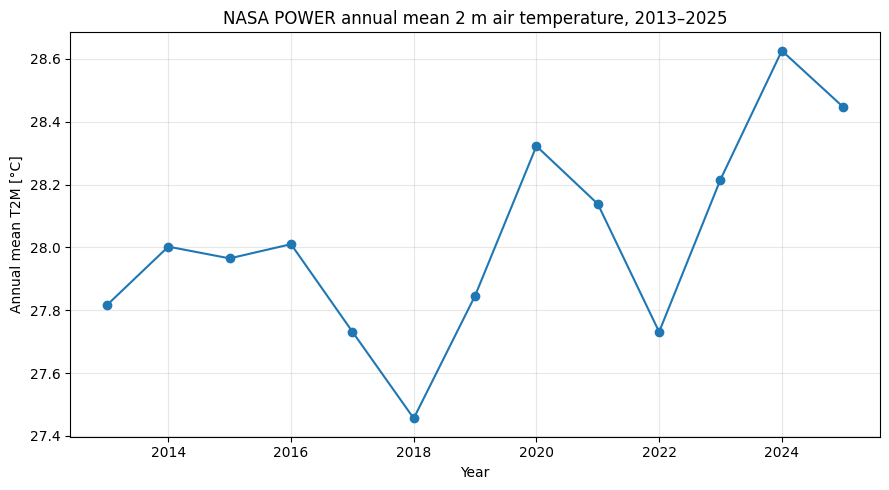

Saved figure: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/figures/05_annual_t2m_mean_2013_2025.png


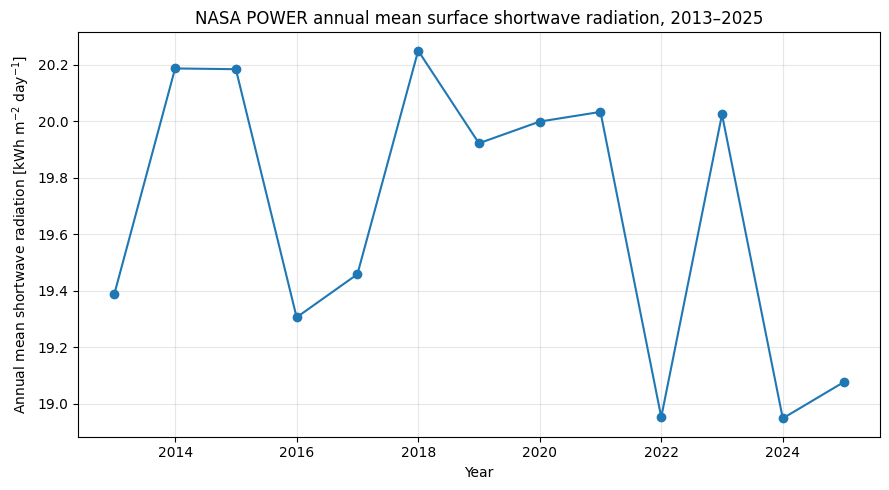

Saved figure: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/figures/05_annual_solar_radiation_mean_2013_2025.png


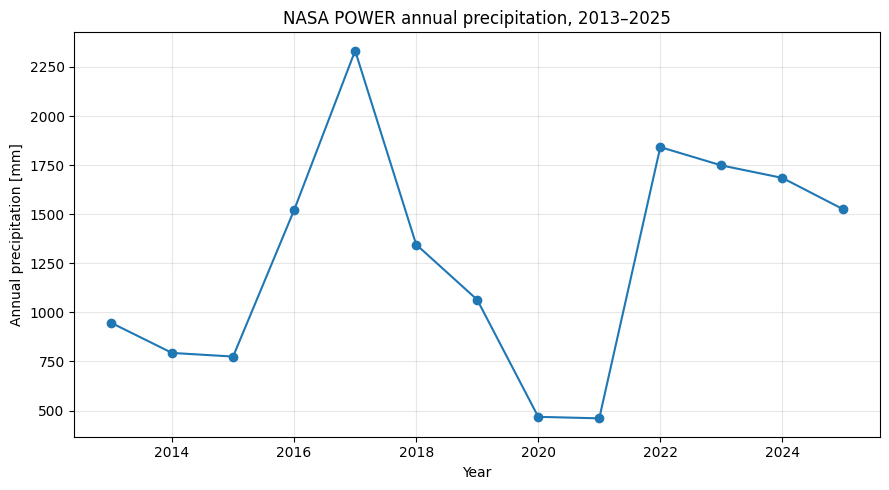

Saved figure: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/figures/05_annual_precip_total_2013_2025.png


In [13]:
# ============================================================
# CELL 13 — Annual climate descriptor figures
# ============================================================

figures_manifest = []


def plot_annual_series(df, y_col, ylabel, title, filename):
    out_path = FIG05_DIR / filename
    plt.figure(figsize=(9, 5))
    plt.plot(df["year"], df[y_col], marker="o")
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    save_current_fig(out_path)
    figures_manifest.append({
        "figure": filename,
        "path": str(out_path),
        "description": title,
        "github_target": "docs/figures/climate_forcings/",
    })


plot_annual_series(
    annual_climate_complete_df,
    "t2m_mean",
    "Annual mean T2M [°C]",
    "NASA POWER annual mean 2 m air temperature, 2013–2025",
    "05_annual_t2m_mean_2013_2025.png",
)

plot_annual_series(
    annual_climate_complete_df,
    "solar_radiation_mean",
    "Annual mean shortwave radiation [kWh m$^{-2}$ day$^{-1}$]",
    "NASA POWER annual mean surface shortwave radiation, 2013–2025",
    "05_annual_solar_radiation_mean_2013_2025.png",
)

plot_annual_series(
    annual_climate_complete_df,
    "precip_total",
    "Annual precipitation [mm]",
    "NASA POWER annual precipitation, 2013–2025",
    "05_annual_precip_total_2013_2025.png",
)


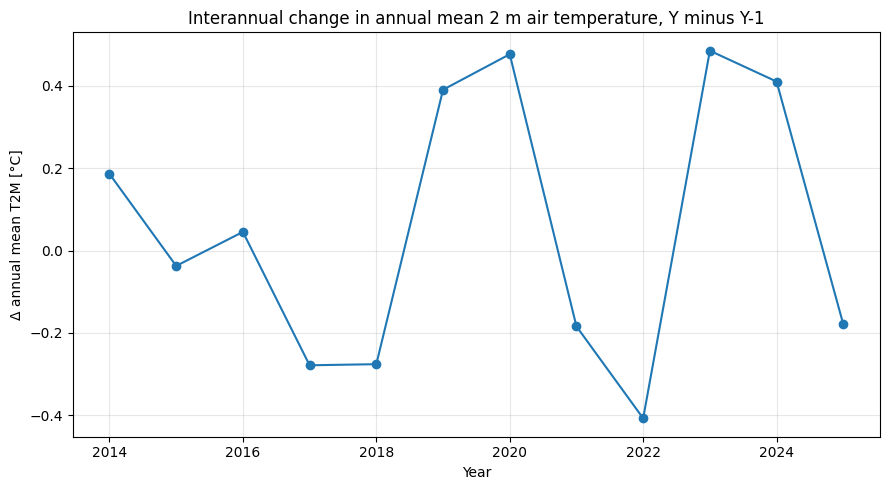

Saved figure: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/figures/05_interannual_delta_t2m_2014_2025.png


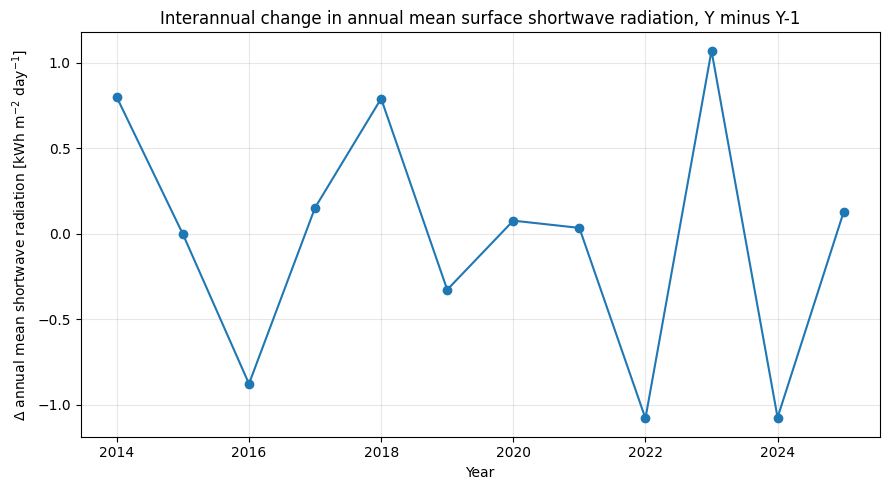

Saved figure: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/figures/05_interannual_delta_solar_radiation_2014_2025.png


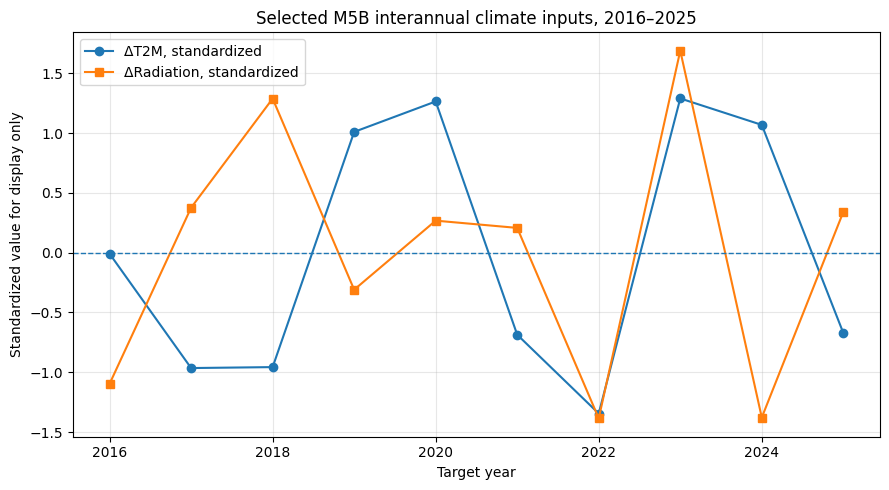

Saved figure: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/figures/05_selected_climate_inputs_m5b_2016_2025.png
Figures manifest: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_climate_forcing_figures_manifest_2013_2025.csv


,figure,path,description,github_target
0,05_annual_t2m_mean_2013_2025.png,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"NASA POWER annual mean 2 m air temperature, 20...",docs/figures/climate_forcings/
1,05_annual_solar_radiation_mean_2013_2025.png,/content/drive/MyDrive/Barranquilla_LST_2013_2...,NASA POWER annual mean surface shortwave radia...,docs/figures/climate_forcings/
2,05_annual_precip_total_2013_2025.png,/content/drive/MyDrive/Barranquilla_LST_2013_2...,"NASA POWER annual precipitation, 2013–2025",docs/figures/climate_forcings/
3,05_interannual_delta_t2m_2014_2025.png,/content/drive/MyDrive/Barranquilla_LST_2013_2...,Interannual change in annual mean 2 m air temp...,docs/figures/climate_forcings/
4,05_interannual_delta_solar_radiation_2014_2025...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,Interannual change in annual mean surface shor...,docs/figures/climate_forcings/
5,05_selected_climate_inputs_m5b_2016_2025.png,/content/drive/MyDrive/Barranquilla_LST_2013_2...,Standardized visual comparison of final select...,docs/figures/climate_forcings/


In [14]:
# ============================================================
# CELL 14 — Interannual delta figures
# ============================================================

delta_plot_df = annual_with_deltas_df[annual_with_deltas_df["year"] >= START_YEAR + 1].copy()

plot_annual_series(
    delta_plot_df,
    "delta_t2m_mean_Y_minus_Yminus1",
    "Δ annual mean T2M [°C]",
    "Interannual change in annual mean 2 m air temperature, Y minus Y-1",
    "05_interannual_delta_t2m_2014_2025.png",
)

plot_annual_series(
    delta_plot_df,
    "delta_solar_radiation_mean_Y_minus_Yminus1",
    "Δ annual mean shortwave radiation [kWh m$^{-2}$ day$^{-1}$]",
    "Interannual change in annual mean surface shortwave radiation, Y minus Y-1",
    "05_interannual_delta_solar_radiation_2014_2025.png",
)

# Standardized comparison figure for selected M5B climate inputs.
selected_plot_df = model_climate_inputs_df[["year"] + SELECTED_CLIMATE_INPUTS].copy()
selected_plot_df["delta_t2m_z_for_plot"] = zscore_for_plot(selected_plot_df["delta_t2m_mean_Y_minus_Yminus1"])
selected_plot_df["delta_radiation_z_for_plot"] = zscore_for_plot(selected_plot_df["delta_solar_radiation_mean_Y_minus_Yminus1"])

out_path = FIG05_DIR / "05_selected_climate_inputs_m5b_2016_2025.png"
plt.figure(figsize=(9, 5))
plt.plot(selected_plot_df["year"], selected_plot_df["delta_t2m_z_for_plot"], marker="o", label="ΔT2M, standardized")
plt.plot(selected_plot_df["year"], selected_plot_df["delta_radiation_z_for_plot"], marker="s", label="ΔRadiation, standardized")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Target year")
plt.ylabel("Standardized value for display only")
plt.title("Selected M5B interannual climate inputs, 2016–2025")
plt.grid(True, alpha=0.3)
plt.legend()
save_current_fig(out_path)
figures_manifest.append({
    "figure": out_path.name,
    "path": str(out_path),
    "description": "Standardized visual comparison of final selected M5B climate inputs.",
    "github_target": "docs/figures/climate_forcings/",
})

FIGURES_MANIFEST_CSV = QC05_DIR / "05_climate_forcing_figures_manifest_2013_2025.csv"
pd.DataFrame(figures_manifest).to_csv(FIGURES_MANIFEST_CSV, index=False)
print("Figures manifest:", FIGURES_MANIFEST_CSV)
display(pd.DataFrame(figures_manifest))


In [15]:
# ============================================================
# CELL 15 — Summary JSON and bitácora
# ============================================================

outputs = {
    "domain_point_json": str(DOMAIN_POINT_JSON),
    "request_metadata_json": str(POWER_REQUEST_METADATA_JSON),
    "request_execution_json": str(REQUEST_EXECUTION_JSON),
    "raw_json": str(RAW_JSON_PATH),
    "daily_csv": str(DAILY_CSV),
    "availability_csv": str(AVAILABILITY_CSV),
    "availability_json": str(AVAILABILITY_JSON),
    "annual_climate_csv": str(ANNUAL_CSV),
    "anomaly_csv": str(ANOMALY_CSV),
    "delta_csv": str(DELTAS_CSV),
    "model_inputs_csv": str(MODEL_INPUTS_CSV),
    "selection_trace_csv": str(SELECTION_TRACE_CSV),
    "figures_manifest_csv": str(FIGURES_MANIFEST_CSV),
    "figures_dir": str(FIG05_DIR),
}

summary = {
    "module": "05_climate_forcing_integration",
    "notebook": "05_climate_forcing_integration.ipynb",
    "source": "NASA POWER Daily API",
    "operational_period": [START_YEAR, END_YEAR],
    "target_years": TARGET_YEARS,
    "domain_point": DOMAIN_POINT,
    "power_parameters": POWER_PARAMETERS,
    "complete_years": complete_years,
    "incomplete_years": incomplete_years,
    "selected_m5b_climate_inputs": SELECTED_CLIMATE_INPUTS,
    "not_pixel_level_rasters": True,
    "methodological_decision": (
        "NASA POWER variables are annual regional descriptors associated with the model-domain centroid. "
        "The final M5B model retains only interannual changes in annual mean 2 m air temperature and "
        "annual mean surface shortwave radiation. Other climate descriptors are documented as evaluated but not retained."
    ),
    "outputs": outputs,
    "timestamp_utc": datetime.utcnow().isoformat() + "Z",
}

SUMMARY_JSON = QC05_DIR / "05_climate_forcing_integration_summary_2013_2025.json"
save_json(summary, SUMMARY_JSON)

BITACORA_MD = BITACORA_DIR / "bitacora_05_climate_forcing_integration_2013_2025.md"

bitacora_text = f"""# Bitácora — 05 Climate forcing integration from NASA POWER, 2013–2025

## Objective

Build and audit annual NASA POWER climate forcing variables for the Barranquilla LST/SUHI modeling workflow, derive anomalies and interannual deltas, and document the final selected climate inputs for M5B.

## Source

- Source: NASA POWER Daily API
- Spatial reference: model-domain centroid
- Operational period: {START_YEAR}–{END_YEAR}
- Target years: {TARGET_START_YEAR}–{TARGET_END_YEAR}

## Domain point

```json
{json.dumps(DOMAIN_POINT, indent=2, ensure_ascii=False)}
```

## NASA POWER parameters

```text
{', '.join(POWER_PARAMETERS)}
```

## Complete years

```text
{complete_years}
```

## Final climate inputs retained for M5B

```text
{SELECTED_CLIMATE_INPUTS}
```

## Methodological note

NASA POWER variables are used as annual regional climate descriptors associated with the model-domain centroid. They must not be interpreted as pixel-level spatial raster predictors.

The final M5B climate input set is intentionally minimal. It retains only interannual deltas in 2 m air temperature and surface shortwave radiation because these variables are physically interpretable and aligned with the T3 temporal formulation, in which antecedent annual states Y-3, Y-2, and Y-1 are used to predict target year Y.

## Files generated

```text
{chr(10).join(outputs.values())}
```

## GitHub upload policy

Upload lightweight CSV, JSON, and markdown reports to:

```text
data/climate_forcings/
```

Upload PNG diagnostic figures to:

```text
docs/figures/climate_forcings/
```

Do not upload raw heavy raster products, tensors, model checkpoints, or full-resolution prediction outputs.
"""

BITACORA_MD.write_text(bitacora_text, encoding="utf-8")
print("Summary JSON:", SUMMARY_JSON)
print("Bitácora:", BITACORA_MD)
print(bitacora_text[:3000])


Saved JSON: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_climate_forcing_integration_summary_2013_2025.json
Summary JSON: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_climate_forcing_integration_summary_2013_2025.json
Bitácora: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/bitacoras/bitacora_05_climate_forcing_integration_2013_2025.md
# Bitácora — 05 Climate forcing integration from NASA POWER, 2013–2025

## Objective

Build and audit annual NASA POWER climate forcing variables for the Barranquilla LST/SUHI modeling workflow, derive anomalies and interannual deltas, and document the final selected climate inputs for M5B.

## Source

- Source: NASA POWER Daily API
- Spatial reference: model-domain centroid
- Operational period: 2013–2025
- Target years: 2016–2025

## Domain poin

In [16]:
# ============================================================
# CELL 16 — Final report
# ============================================================

print("=" * 80)
print("05_climate_forcing_integration.ipynb finished")
print("=" * 80)
print("Output directory:", QC05_DIR)
print("Figures directory:", FIG05_DIR)
print("Main GitHub-ready reports:")
for p in [
    DAILY_CSV,
    AVAILABILITY_CSV,
    ANNUAL_CSV,
    ANOMALY_CSV,
    DELTAS_CSV,
    MODEL_INPUTS_CSV,
    SELECTION_TRACE_CSV,
    FIGURES_MANIFEST_CSV,
    SUMMARY_JSON,
    BITACORA_MD,
]:
    print(" -", p)
print("\nUpload CSV/JSON/MD reports to: data/climate_forcings/")
print("Upload PNG figures to: docs/figures/climate_forcings/")
print("Upload this notebook to: notebooks/05_climate_forcing_integration.ipynb")


05_climate_forcing_integration.ipynb finished
Output directory: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025
Figures directory: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/figures
Main GitHub-ready reports:
 - /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_nasa_power_daily_2013_2025.csv
 - /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_nasa_power_year_availability_2013_2025.csv
 - /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/05_climate_forcing_integration_2013_2025/05_annual_climate_forcing_nasa_power_2013_2025.csv
 - /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentatio